# AAV9 real data — profile model

This notebook works with `aav9.csv`, a real NGS dataset from an AAV9 capsid
directed-evolution / viability experiment (not the simulated `Protocol` used
elsewhere in `Modelization_V1`). Each row is one observed 7-amino-acid variant
(the same `(num_amino_acids=20, num_positions=7)` convention as
`sequence_classesV1.Protocol`) with:


- `target` — the log enrichment of post-viability count over the input `plasmid` pool,
- `error` — an estimated uncertainty on `target` (bounded in `[0, 2]`; smaller
  for variants with more reads)

**Goal of this notebook (task 1):** build the **profile model** — the same
`F` object as `Protocol.F_viab`, a
`(num_amino_acids, num_positions)` matrix where `F[a, i]` says how good/bad
amino acid `a` is at position `i`. The logic being encoded is literally: *if
sequences with amino acid A at position 1 tend to have high (good) log
enrichment, position 1 / AA-A gets a positive profile weight* — and
symmetrically for every other (amino acid, position) pair.

In [1]:
import os
print(os.getcwd())

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/notebooks/aav_viability_test


### 0. Setup

In [2]:
import sys, os

# This notebook lives in "Modelization_V1/MLP regression/AAV viability test/", two levels
# below analysisV1.py / sequence_classesV1.py -- add Modelization_V1 so those sibling
# imports resolve (same convention as ProfileMLP_recovery_nnx.ipynb, one level up).
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes (analysisV1 imports jax)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

from analysisV1 import AA_LABELS, pearson, precision_at_k, plot_teacher_weights, plot_topk_recovery

# Only needed for section 8 (ProfileMLP), imported here so section 0 is the single setup point.
import jax
import jax.numpy as jnp
from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm
from sequence_classesV1 import ProtocolV2, initialize_random_weights

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

message = "AAV9 real-data profile model 1.1"


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


### 1. Load the data

In [3]:
df = pd.read_csv("aav9.csv")
print(f"{len(df):,} variants, columns: {list(df.columns)}")
df.head()


68,776 variants, columns: ['sequence', 'target', 'error']


,sequence,target,error
0,AAACMFE,-7.167889,0.1
1,AAAFQEE,0.815779,0.1
2,AAAGCEN,-5.382741,0.1
3,AAALKGI,0.441829,0.1
4,AAANGCQ,-4.548073,0.1


### 1b. Target distribution

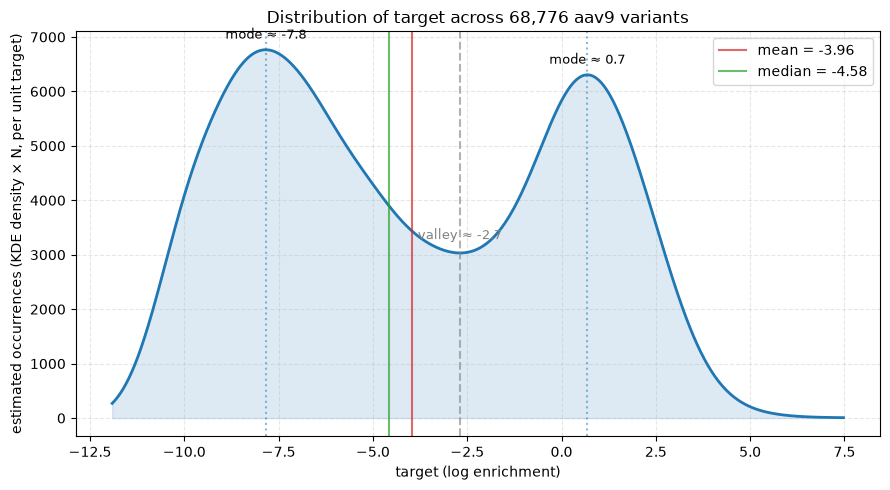

detected mode(s) at target ≈ [-7.84  0.68]


In [4]:
t = df["target"].to_numpy()

# Smooth density (Gaussian KDE), not a binned histogram -- rescaled by N so the curve reads
# as an estimated occurrence count per unit of target (area under the curve over a range ~=
# expected number of variants in that range), rather than a probability density.
grid = np.linspace(t.min(), t.max(), 1000)
kde = gaussian_kde(t, bw_method=0.15)
occurrences = kde(grid) * len(t)

# Auto-detect modes (and, if bimodal, the valley between them) instead of eyeballing the plot.
peaks, _ = find_peaks(occurrences, prominence=occurrences.max() * 0.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grid, occurrences, color="tab:blue", lw=2)
ax.fill_between(grid, occurrences, alpha=0.15, color="tab:blue")

for p in peaks:
    ax.axvline(grid[p], color="tab:blue", linestyle=":", alpha=0.5)
    ax.annotate(f"mode ≈ {grid[p]:.1f}", (grid[p], occurrences[p]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

if len(peaks) >= 2:
    lo, hi = peaks[0], peaks[-1]
    valley = lo + np.argmin(occurrences[lo:hi + 1])
    ax.axvline(grid[valley], color="gray", linestyle="--", alpha=0.6)
    ax.annotate(f"valley ≈ {grid[valley]:.1f}", (grid[valley], occurrences[valley]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="gray")

ax.axvline(t.mean(), color="tab:red", linestyle="-", alpha=0.7, label=f"mean = {t.mean():.2f}")
ax.axvline(np.median(t), color="tab:green", linestyle="-", alpha=0.7, label=f"median = {np.median(t):.2f}")

ax.set_xlabel("target (log enrichment)")
ax.set_ylabel("estimated occurrences (KDE density × N, per unit target)")
ax.set_title(f"Distribution of target across {len(t):,} aav9 variants")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"detected mode(s) at target ≈ {np.round(grid[peaks], 2)}")


In [5]:
lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
num_positions = int(lengths[0])
num_amino_acids = len(AA_LABELS)

alphabet = sorted(set("".join(df["sequence"])))
assert alphabet == AA_LABELS, f"alphabet mismatch: {alphabet} vs {AA_LABELS}"

print(f"num_positions={num_positions}  num_amino_acids={num_amino_acids}")

df[["target", "error"]].describe()


num_positions=7  num_amino_acids=20


,target,error
count,68776.000000,6.877600e+04
mean,-3.959911,1.000000e-01
std,4.209564,1.387789e-17
min,-11.911773,1.000000e-01
25%,-7.710318,1.000000e-01
50%,-4.583340,1.000000e-01
75%,0.087531,1.000000e-01
max,7.472986,1.000000e-01


In [6]:
lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), num_positions)
target = df["target"].to_numpy()

print(f"seq_matrix shape: {seq_matrix.shape}  (num_sequences, num_positions)")
print(f"seq_matrix[0] = {seq_matrix[0]}  ->  '{df['sequence'].iloc[0]}'")

seq_matrix shape: (68776, 7)  (num_sequences, num_positions)
seq_matrix[0] = [ 0  0  0  1 10  4  3]  ->  'AAACMFE'


### 2. Building a supposed Ground Truth 

In [7]:
def F_groundtruth_viability(seq_matrix, target, num_amino_acids, num_positions):
    baseline = target.mean()
    F = np.full((num_amino_acids, num_positions), np.nan)
    counts = np.zeros((num_amino_acids, num_positions), dtype=int)
    for i in range(num_positions):
        for aa in range(num_amino_acids):
            mask = seq_matrix[:, i] == aa
            counts[aa, i] = mask.sum()
            if mask.any():
                F[aa, i] = target[mask].mean() - baseline
    return F, counts

F_viab_GT, counts = F_groundtruth_viability(seq_matrix=seq_matrix, target=df['target'].to_numpy(), num_amino_acids=num_amino_acids, num_positions=num_positions)

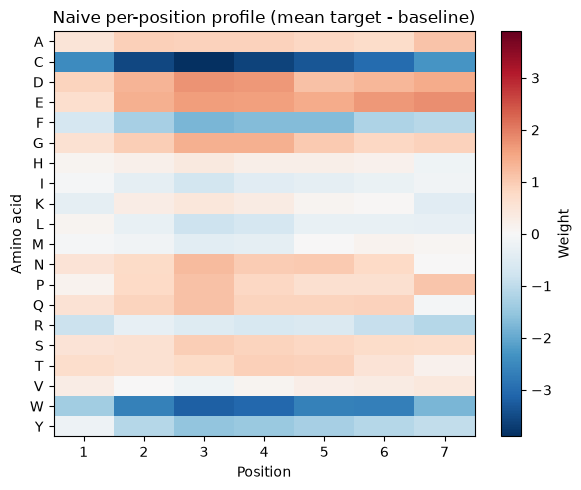

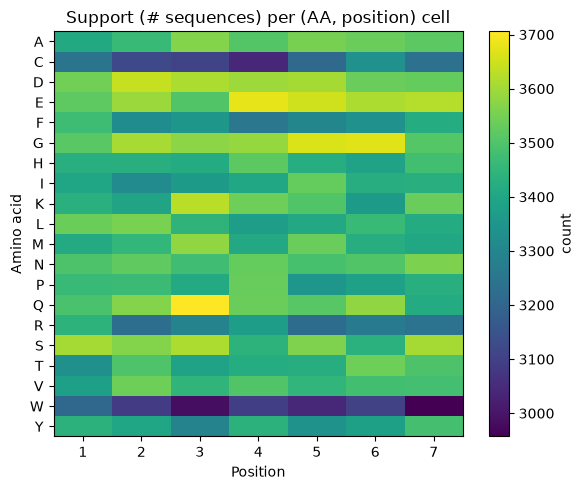

In [8]:
plot_teacher_weights(F_viab_GT, title="Naive per-position profile (mean target - baseline)")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(counts, aspect="auto", cmap="viridis")
ax.set_xlabel("Position")
ax.set_ylabel("Amino acid")
ax.set_xticks(range(num_positions))
ax.set_xticklabels([str(i) for i in range(1, num_positions + 1)])
ax.set_yticks(range(num_amino_acids))
ax.set_yticklabels(AA_LABELS)
ax.set_title("Support (# sequences) per (AA, position) cell")
fig.colorbar(im, ax=ax, label="count")
fig.tight_layout()
plt.show()


### 3. Learning the profile weights with an MLP

In [9]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Same building blocks as SimpleMLP
    (Linear + BatchNorm + Dropout + gelu), with input_dim=L*A: one-hot gives the network
    the categorical amino-acid structure for free, so it only has to learn each position's
    per-amino-acid effect -- and any pairwise coupling -- on top of that, instead of also
    having to rediscover the categorical structure from a raw integer index.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


In [10]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


In [11]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True, model=None):
    """
    model : optional existing ProfileMLP to continue training from (warm start) instead of
    initializing a fresh one.
    """
    rngs = nnx.Rngs(seed)
    if model is None:
        model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                            dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


In [12]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.5, random_state=0)
y_train, y_test    = target[idx_train], target[idx_test]

### ------------ One Hot Encoding ------------ ###
# Raw per-position indices (0..19, AA_LABELS' alphabetical order) carry no numeric
# meaning -- amino acid 3 isn't "between" 2 and 4 in any biological sense -- so feeding
# them straight into nnx.Linear as floats forces the network to first rediscover the
# one-hot structure from scratch before it can learn anything else. One-hot expands
# each position into a length-20 indicator vector instead: (N, 7) -> (N, 7, 20) -> (N, 140).
seq_oh = np.eye(num_amino_acids, dtype=np.float32)[seq_matrix]  # (N, L, A)
seq_oh = seq_oh.reshape(len(df), -1)                             # (N, L*A)

X_mlp_train_full = seq_oh[idx_train]
X_mlp_test        = seq_oh[idx_test]

print(f"X_mlp_train_full shape is {X_mlp_train_full.shape}")

Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp = split_train_val(X_mlp_train_full, y_train, val_frac=0.15, seed=0)
print(f"ProfileMLP -- train: {len(Xtr_mlp):,}  val: {len(Xva_mlp):,}  test: {len(X_mlp_test):,}")

model_mlp, hist_mlp = train_profile_mlp(Xtr_mlp, ytr_mlp, Xva_mlp, yva_mlp, seed=0)


X_mlp_train_full shape is (34388, 140)
ProfileMLP -- train: 29,230  val: 5,158  test: 34,388



Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]


Training ProfileMLP:   0%|          | 1/300 [00:04<22:01,  4.42s/it]


Training ProfileMLP:   3%|▎         | 8/300 [00:04<02:01,  2.40it/s]


Training ProfileMLP:   5%|▍         | 14/300 [00:04<00:58,  4.85it/s]

...


Training ProfileMLP:  15%|█▌        | 45/300 [00:05<00:09, 27.52it/s]


Training ProfileMLP:  17%|█▋        | 51/300 [00:05<00:07, 33.02it/s]


Training ProfileMLP:  19%|█▉        | 58/300 [00:05<00:06, 39.20it/s]


Training ProfileMLP:  20%|██        | 61/300 [00:05<00:21, 11.20it/s]

Early stopping at epoch 61 (best val MSE=3.0313)


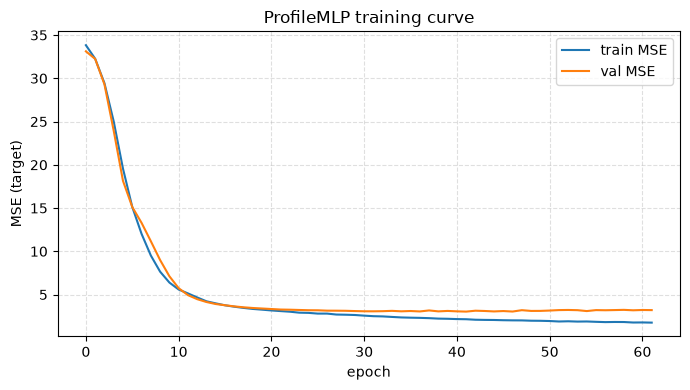

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_mlp["train_loss"], label="train MSE")
ax.plot(hist_mlp["val_loss"],   label="val MSE")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (target)")
ax.set_title("ProfileMLP training curve")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
This is a top-k% precision/recovery check restricted to the <b>held-out test split</b> (<code>idx_test</code>, ~34,388 of the 68,776 real aav9.csv sequences) — not the full library and not a brute-force theoretical population. It measures whether the model's own ranking on unseen real data recovers the true best sequences.
</div>

Pearson r (train): 0.9676
Pearson r (test):  0.9134

Held-out (test) top-k recovery:
  Top   1%   precision = 0.155   (random baseline = 0.010)
  Top   5%   precision = 0.422   (random baseline = 0.050)
  Top  10%   precision = 0.582   (random baseline = 0.100)
  Top  20%   precision = 0.741   (random baseline = 0.200)


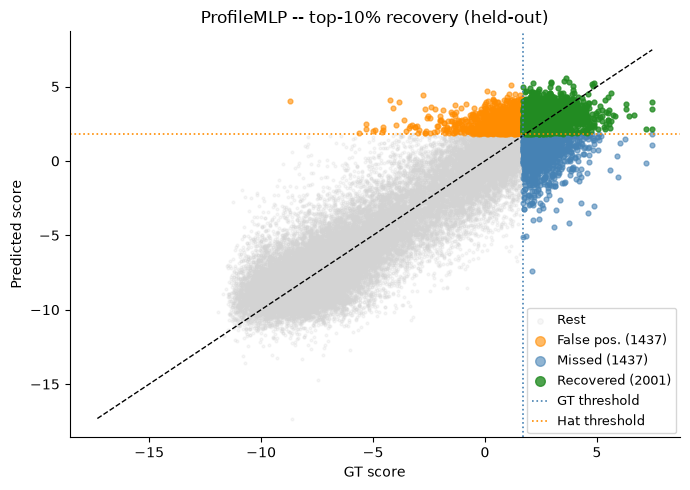

In [14]:
@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)

pred_train_mlp = np.asarray(predict_scores(model_mlp, jnp.asarray(Xtr_mlp)))
pred_test_mlp  = np.asarray(predict_scores(model_mlp, jnp.asarray(X_mlp_test)))

print(f"Pearson r (train): {pearson(ytr_mlp, pred_train_mlp):.4f}")
print(f"Pearson r (test):  {pearson(y_test,  pred_test_mlp):.4f}")
print()
print("Held-out (test) top-k recovery:")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_test, pred_test_mlp, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_test, pred_test_mlp, k_frac=0.10, title="ProfileMLP -- top-10% recovery (held-out)")
plt.show()


In [15]:
def extract_effective_F(model, backgrounds, L=num_positions, A=num_amino_acids, batch_size=8192):
    """
    Single-mutant scan against real background sequences: for a background s and mutation
    p->a, M(s^{p->a}) - M(s) isolates f_p(a) only up to terms that depend on s's other
    positions. Averaged over many backgrounds, F is recovered up to a global additive
    constant.

    backgrounds : (M, L) real sequences as raw amino-acid indices, e.g. a random subsample
                  of seq_matrix. Mutants are built in raw-index space (simplest way to flip
                  a single position), then one-hot encoded right before scoring since model
                  now expects one-hot (N, L*A) input, matching training.
    """
    backgrounds = np.asarray(backgrounds, dtype=np.int64)
    M = backgrounds.shape[0]

    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    x_all    = np.concatenate([backgrounds, single_mutants], axis=0)      # (n, L) raw indices
    x_all_oh = np.eye(A, dtype=np.float32)[x_all].reshape(x_all.shape[0], -1)  # (n, L*A) one-hot

    scores_chunks = []
    for start in range(0, x_all_oh.shape[0], batch_size):
        chunk = jnp.asarray(x_all_oh[start : start + batch_size])
        scores_chunks.append(np.asarray(predict_scores(model, chunk)))
    scores = np.concatenate(scores_chunks)

    mean_score    = scores.mean()
    single_scores = scores[M:].reshape(M, L, A)

    F_flat = single_scores.mean(axis=0) - mean_score  # (L, A)
    F_hat  = F_flat.T.astype(np.float32)               # (A, L)
    return F_hat


rng_bg      = np.random.default_rng(0)
M_backgrounds = 256
bg_idx      = rng_bg.choice(seq_matrix.shape[0], size=M_backgrounds, replace=False)
backgrounds = seq_matrix[bg_idx]

F_mlp = extract_effective_F(model_mlp, backgrounds)


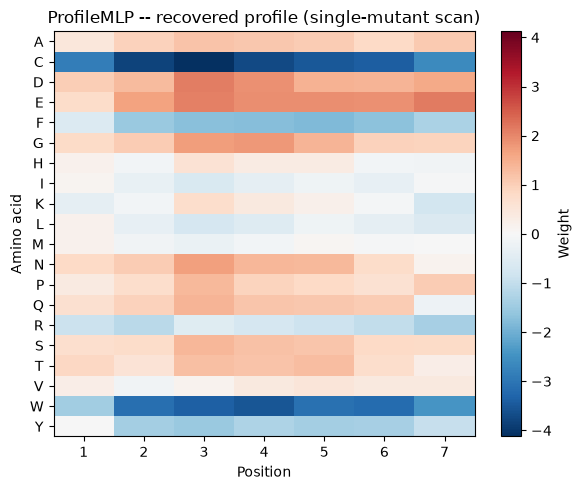

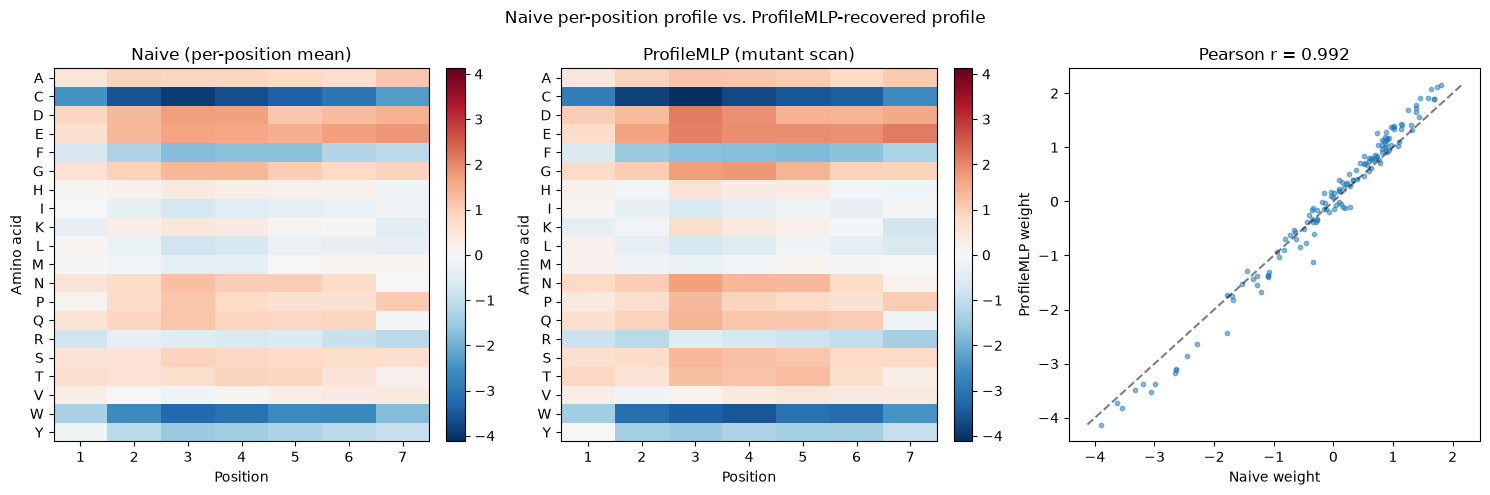

In [16]:
plot_teacher_weights(F_mlp, title="ProfileMLP -- recovered profile (single-mutant scan)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vmax = max(np.abs(F_viab_GT).max(), np.abs(F_mlp).max())

for ax, F, title in [(axes[0], F_viab_GT, "Naive (per-position mean)"), (axes[1], F_mlp, "ProfileMLP (mutant scan)")]:
    im = ax.imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel("Amino acid")
    ax.set_xticks(range(num_positions))
    ax.set_xticklabels([str(i) for i in range(1, num_positions + 1)])
    ax.set_yticks(range(num_amino_acids))
    ax.set_yticklabels(AA_LABELS)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

r_profiles = pearson(F_viab_GT.ravel(), F_mlp.ravel())
axes[2].scatter(F_viab_GT.ravel(), F_mlp.ravel(), s=10, alpha=0.5)
lims = [min(F_viab_GT.min(), F_mlp.min()), max(F_viab_GT.max(), F_mlp.max())]
axes[2].plot(lims, lims, "k--", alpha=0.5)
axes[2].set_xlabel("Naive weight")
axes[2].set_ylabel("ProfileMLP weight")
axes[2].set_title(f"Pearson r = {r_profiles:.3f}")

fig.suptitle("Naive per-position profile vs. ProfileMLP-recovered profile")
fig.tight_layout()
plt.show()


### 3b. Pairwise (J) interactions: naive vs ProfileMLP

Section 2's naive profile only captures each position's own AVERAGE effect — it can't see
whether two positions interact (e.g. amino acid A being good at position 1 only when
position 4 has amino acid B). This extends the same two recipes already used for `F` to the
pairwise coupling `J`:

- **Naive J** — the same "group real sequences and average their target" logic as
  `F_groundtruth_viability`, extended to position PAIRS: for every (position i, position j,
  amino acid a, amino acid b), average the target of sequences that actually carry (a at i)
  AND (b at j), then subtract off the baseline and each position's own naive single-site
  effect (already known from `F_viab_GT`) — what's left over is the naive pairwise term.
- **ProfileMLP J** — `extract_effective_F`'s single-mutant scan extended to a DOUBLE-mutant
  scan against the already-trained `model_mlp` (same idea as `extract_effective_FJ` in
  `DEEPMLP_nnx_recovery.ipynb`, minus that notebook's `T` temperature scaling — real `target`
  isn't on that simulated scale).

The two are then compared directly: per-position-pair coupling-strength heatmaps side by
side, plus a raw-entry scatter restricted to cells where the naive estimate had enough real
sequences behind it to be trustworthy.

In [17]:
def J_groundtruth_naive(seq_matrix, target, F, baseline, num_amino_acids, num_positions, min_support=5):
    """
    Naive per-pair pairwise-interaction estimate: for every position pair (i, j) and
    amino-acid pair (a, b), take the mean target of the real sequences that actually carry
    (a at i) AND (b at j), then subtract off what the baseline and each position's own
    single-site naive effect (F[a, i], F[b, j]) already explain -- what's left over is the
    naive estimate of positions i/j's PAIRWISE (epistatic) contribution, J[i, j, a, b].
    Mirrors J[j, i, b, a] = J[i, j, a, b], matching sequence_classesV1.build_J's convention.
    Cells with fewer than min_support supporting sequences are left as NaN (too few
    observations to trust the mean) -- same convention as F_groundtruth_viability's counts.

    Returns
    -------
    J, support : (L, L, A, A) naive interaction estimate (NaN on the diagonal i==j, and on
    any (i, j, a, b) with too little support) and the (L, L, A, A) raw supporting-sequence
    counts (useful to judge how much to trust a given cell).
    """
    L, A = num_positions, num_amino_acids
    J = np.full((L, L, A, A), np.nan)
    support = np.zeros((L, L, A, A), dtype=int)

    # Precompute each position's per-amino-acid boolean mask once, reused across every
    # partner position instead of recomputing "sequence has amino acid a at position i"
    # A*(L-1) times.
    position_masks = [[seq_matrix[:, i] == a for a in range(A)] for i in range(L)]

    for i in range(L):
        for j in range(i + 1, L):
            for a in range(A):
                mask_a = position_masks[i][a]
                if not mask_a.any():
                    continue
                for b in range(A):
                    mask = mask_a & position_masks[j][b]
                    n = int(mask.sum())
                    support[i, j, a, b] = support[j, i, b, a] = n
                    if n >= min_support:
                        val = target[mask].mean() - baseline - F[a, i] - F[b, j]
                        J[i, j, a, b] = J[j, i, b, a] = val
    return J, support


J_naive, support_naive = J_groundtruth_naive(
    seq_matrix, target, F_viab_GT, baseline=target.mean(),
    num_amino_acids=num_amino_acids, num_positions=num_positions, min_support=5,
)

off_diag = ~np.eye(num_positions, dtype=bool)
print(f"J_naive: {(~np.isnan(J_naive)).sum():,} / {J_naive.size:,} cells filled "
      f"({np.isnan(J_naive[off_diag]).mean() * 100:.1f}% of off-diagonal cells still NaN, "
      f"median support {np.median(support_naive[off_diag]):.0f} sequences/cell)")


J_naive: 16,800 / 19,600 cells filled (0.0% of off-diagonal cells still NaN, median support 172 sequences/cell)


In [18]:
def extract_effective_FJ_mlp(model, backgrounds, L=num_positions, A=num_amino_acids, batch_size=8192):
    """
    Double-mutant scan against the same `backgrounds` used by `extract_effective_F`'s
    single-mutant scan: for a background s and a JOINT mutation (p->a, q->b),
    M(s^{p->a,q->b}) - M(s) isolates f_p(a) + f_q(b) + j_pq(a,b), up to terms that depend on
    s's other positions. Averaged over backgrounds, subtracting the single-site effects
    (recomputed here from the SAME scan, so they're self-consistent with the pairwise term)
    leaves j_pq(a,b) -- the model's own effective pairwise coupling. Same "zero-sum-gauge"
    caveat as DEEPMLP_nnx_recovery.ipynb's extract_effective_FJ (each position's row/column
    mean is already subtracted out of J), but with no `T` scaling: this model was trained
    directly on the real (already-log-scale) target, unlike the simulated Protocol's
    T-normalized scores.

    Returns
    -------
    F_hat, J_hat : (A, L) single-site effects (same convention as extract_effective_F) and
    (L, L, A, A) pairwise couplings (NaN on the diagonal i==j, where "interaction" is
    undefined).
    """
    backgrounds = np.asarray(backgrounds, dtype=np.int64)
    M = backgrounds.shape[0]

    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    pairs    = [(i, j) for i in range(L) for j in range(i + 1, L)]
    n_pairs  = len(pairs)
    n_double = M * n_pairs * A * A
    double_mutants = np.repeat(backgrounds, n_pairs * A * A, axis=0)
    pair_pattern   = np.repeat(np.arange(n_pairs), A * A)
    aai_block      = np.repeat(np.arange(A), A)
    aaj_block      = np.tile(np.arange(A), A)
    i_of_pair      = np.array([p[0] for p in pairs])
    j_of_pair      = np.array([p[1] for p in pairs])
    tiled_i        = np.tile(i_of_pair[pair_pattern], M)
    tiled_j        = np.tile(j_of_pair[pair_pattern], M)
    tiled_aai      = np.tile(np.tile(aai_block, n_pairs), M)
    tiled_aaj      = np.tile(np.tile(aaj_block, n_pairs), M)
    rows           = np.arange(n_double)
    double_mutants[rows, tiled_i] = tiled_aai
    double_mutants[rows, tiled_j] = tiled_aaj

    x_all = np.concatenate([backgrounds, single_mutants, double_mutants], axis=0)  # (n, L) raw indices

    # One-hot encoded and scored batch by batch -- x_all alone is ~2.2M rows here (256
    # backgrounds x (1 + L*A + n_pairs*A*A) mutants each), encoding it to one-hot all at once
    # would briefly need >1GB; chunking keeps peak memory small.
    scores_chunks = []
    for start in range(0, x_all.shape[0], batch_size):
        chunk_oh = np.eye(A, dtype=np.float32)[x_all[start : start + batch_size]].reshape(-1, L * A)
        scores_chunks.append(np.asarray(predict_scores(model, jnp.asarray(chunk_oh))))
    scores = np.concatenate(scores_chunks)

    mean_score    = scores.mean()
    single_scores = scores[M : M + n_single].reshape(M, L, A)
    double_scores = scores[M + n_single :].reshape(M, n_pairs, A, A)

    F_flat = single_scores.mean(axis=0) - mean_score  # (L, A)
    F_hat  = F_flat.T.astype(np.float32)               # (A, L), matches extract_effective_F

    double_avg = double_scores.mean(axis=0)  # (n_pairs, A, A)
    J_hat = np.full((L, L, A, A), np.nan, dtype=np.float32)
    for k, (i, j) in enumerate(pairs):
        delta_ij    = double_avg[k] - mean_score - F_flat[i][:, None] - F_flat[j][None, :]
        J_hat[i, j] = delta_ij
        J_hat[j, i] = delta_ij.T
    return F_hat, J_hat


F_mlp_fj, J_mlp = extract_effective_FJ_mlp(model_mlp, backgrounds)
print(f"Pearson r (F_mlp_fj vs F_mlp, sanity check -- same scan run twice): "
      f"{pearson(F_mlp.ravel(), F_mlp_fj.ravel()):.4f}")


Pearson r (F_mlp_fj vs F_mlp, sanity check -- same scan run twice): 1.0000


In [19]:
# Export F_viab and J_viab for use elsewhere in the project (Modelization_V1/initialize_weights.py),
# so simulations can be seeded with REAL AAV9-derived weights instead of synthetic random
# ones. Saved two directories up, alongside sequence_classesV1.py -- .npy files are
# gitignored (a derived artifact, not source), so just re-run this cell any time model_mlp is
# retrained to refresh both. J_mlp's diagonal (i == j, undefined "self interaction") is
# zeroed before saving, matching sequence_classesV1.build_J's convention (Protocol's J
# tensors are never NaN, only ever exactly 0 where there's no interaction).
F_VIAB_EXPORT_PATH = os.path.join("..", "..", "aav9_F_viab_mlp.npy")
J_VIAB_EXPORT_PATH = os.path.join("..", "..", "aav9_J_viab_mlp.npy")

np.save(F_VIAB_EXPORT_PATH, F_mlp)
np.save(J_VIAB_EXPORT_PATH, np.nan_to_num(J_mlp, nan=0.0))

print(f"Saved F_mlp {F_mlp.shape} to {os.path.abspath(F_VIAB_EXPORT_PATH)}")
print(f"Saved J_mlp {J_mlp.shape} to {os.path.abspath(J_VIAB_EXPORT_PATH)}")


Saved F_mlp (20, 7) to /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/aav9_F_viab_mlp.npy
Saved J_mlp (7, 7, 20, 20) to /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/aav9_J_viab_mlp.npy


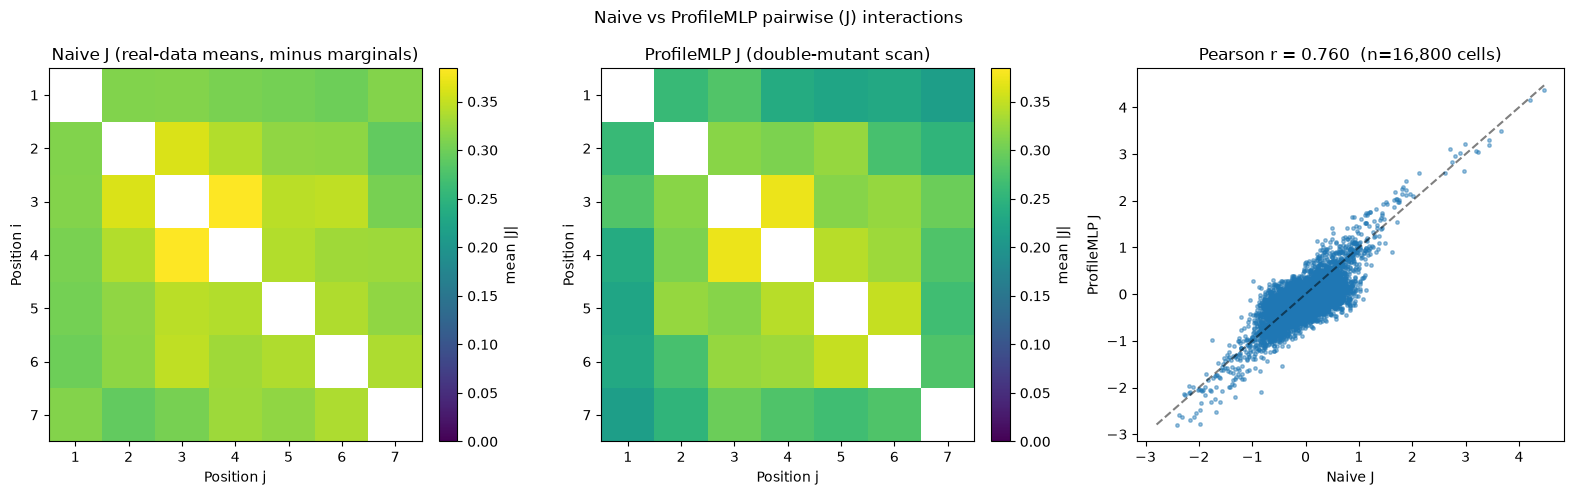

In [20]:
def coupling_strength(J):
    """(L, L, A, A) -> (L, L) mean |J_ij(a, b)| per position pair; NaN cells (no/too little
    support) are skipped rather than propagated, so one sparse cell doesn't NaN out its
    whole (i, j) pair. The diagonal (i == j, "interaction with itself") is left NaN directly,
    without ever calling nanmean on an all-NaN slice (which numpy would warn about)."""
    L = J.shape[0]
    off_diag = ~np.eye(L, dtype=bool)
    strength = np.full((L, L), np.nan)
    strength[off_diag] = np.nanmean(np.abs(J[off_diag]), axis=(1, 2))
    return strength

strength_naive = coupling_strength(J_naive)
strength_mlp   = coupling_strength(J_mlp)
vmax_strength  = np.nanmax([strength_naive, strength_mlp])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, S, title in [(axes[0], strength_naive, "Naive J (real-data means, minus marginals)"),
                      (axes[1], strength_mlp,   "ProfileMLP J (double-mutant scan)")]:
    im = ax.imshow(S, cmap="viridis", vmin=0, vmax=vmax_strength)
    ax.set_xlabel("Position j")
    ax.set_ylabel("Position i")
    ax.set_xticks(range(num_positions)); ax.set_xticklabels(range(1, num_positions + 1))
    ax.set_yticks(range(num_positions)); ax.set_yticklabels(range(1, num_positions + 1))
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="mean |J|", fraction=0.046, pad=0.04)

# Raw-entry scatter, restricted to cells where the naive estimate actually had enough
# supporting sequences (min_support) to be trustworthy -- ProfileMLP's J is defined
# everywhere off-diagonal, but only compared where there's a real naive value to check it
# against.
mask_support = ~np.isnan(J_naive)
j_naive_flat = J_naive[mask_support]
j_mlp_flat   = J_mlp[mask_support]
r_J = pearson(j_naive_flat, j_mlp_flat)

axes[2].scatter(j_naive_flat, j_mlp_flat, s=6, alpha=0.25)
lims = [min(j_naive_flat.min(), j_mlp_flat.min()), max(j_naive_flat.max(), j_mlp_flat.max())]
axes[2].plot(lims, lims, "k--", alpha=0.5)
axes[2].set_xlabel("Naive J")
axes[2].set_ylabel("ProfileMLP J")
axes[2].set_title(f"Pearson r = {r_J:.3f}  (n={mask_support.sum():,} cells)")

fig.suptitle("Naive vs ProfileMLP pairwise (J) interactions")
fig.tight_layout()
plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Top <b>5,000</b> (not 500) sequences over the <b>full</b> real aav9.csv (all 68,776 rows), ranked by <code>model_mlp</code>'s <b>predicted</b> <code>total_score</code> — not the measured target, and not restricted to held-out data. Don't confuse this K=5000 predicted-ranking set (full library) with the K=500 true-target set used later in this notebook (held-out only).
</div>

### 4. Ranking real sequences: total / F / J score breakdown

For every real sequence in `aav9.csv`, decompose the trained `model_mlp`'s score into the
pieces recovered above:

- **`total_score`** — the model's own prediction for that exact sequence (`model_mlp` forward
  pass on its one-hot encoding) — the full black-box score, all orders included.
- **`F_score`** — the single-site (additive) contribution only: `sum_i F_viab[seq_i, i]`,
  using the `F_mlp` profile recovered by the single-mutant scan in section 3.
- **`J_score`** — the pairwise (epistatic) contribution only: `sum_{i<j} J_viab[i, j, seq_i,
  seq_j]`, using the `J_mlp` tensor recovered by the double-mutant scan in section 3b.

`total_score ≈ mean_score + F_score + J_score + (higher-order terms neither scan captures)`.
Sorted by `total_score`, kept to the top 5,000 real sequences.


In [21]:
def batched_predict(model, X_oh, batch_size=8192):
    chunks = []
    for start in range(0, X_oh.shape[0], batch_size):
        chunk = jnp.asarray(X_oh[start : start + batch_size])
        chunks.append(np.asarray(predict_scores(model, chunk)))
    return np.concatenate(chunks)

total_score = batched_predict(model_mlp, seq_oh)

F_score = F_mlp[seq_matrix, np.arange(num_positions)].sum(axis=1)

J_score = np.zeros(len(df), dtype=np.float32)
for i in range(num_positions):
    for j in range(i + 1, num_positions):
        J_score += J_mlp[i, j, seq_matrix[:, i], seq_matrix[:, j]]

print(f"total_score: mean={total_score.mean():.3f}  std={total_score.std():.3f}")
print(f"F_score:     mean={F_score.mean():.3f}  std={F_score.std():.3f}")
print(f"J_score:     mean={J_score.mean():.3f}  std={J_score.std():.3f}")


total_score: mean=-3.925  std=4.237
F_score:     mean=0.345  std=3.520
J_score:     mean=-2.390  std=1.869


In [22]:
scores_df = pd.DataFrame({
    "sequence": df["sequence"].to_numpy(),
    "total_score": total_score,
    "F_score": F_score,
    "J_score": J_score,
    "target": target,
})

top5000_df = scores_df.sort_values("total_score", ascending=False).head(5000).reset_index(drop=True)
top5000_df


,sequence,total_score,F_score,J_score,target
0,NANKAGM,5.590485,5.854305,-0.319760,5.084973
1,TQNLSKS,5.582118,4.811936,0.063718,3.621034
2,YAASSKT,5.577523,4.646099,-0.374239,6.008946
3,VQGKFAG,5.507317,3.233925,0.350209,5.799932
4,TAVKMGA,5.367842,4.477385,-0.346346,3.518347
...,...,...,...,...,...
4995,ERFNMND,2.231654,1.721655,-0.436661,-0.565169
4996,YEKNPYP,2.231620,4.175642,-0.987405,1.304697
4997,QLRALQP,2.231047,2.890358,-1.265806,-0.877217
4998,WSTESAL,2.231043,3.856815,-2.068089,1.659519


### 5. Second-order-only model vs. full model -- isolating overfitting from real higher-order signal

Section 3/3b's `F_mlp`/`J_mlp` were extracted by *probing* the already-trained, unrestricted
`model_mlp` (single/double-mutant scan) -- that only shows `model_mlp` is using *something*
beyond pairs, it can't say whether that something is real biology or overfit noise, since a
probe of a black box can't distinguish "the box learned a real 3-way effect" from "the box
memorized noise that happens to not decompose into pairs".

This section instead trains a **separate, structurally second-order-only model** --
`PairwiseProfileModel`, `score = bias + sum_i F[s_i, i] + sum_{i<j} J[i, j, s_i, s_j]` with `F`
and `J` as the model's ONLY parameters (no room for any 3-way+ term to hide in) -- directly
against the same real, noisy `target`, using the exact same `idx_train`/`idx_test` split as
`model_mlp`. Comparing the two **only on the held-out `idx_test` sequences** (data neither model
was fit to) is what separates the two hypotheses:

- similar test performance -> `model_mlp`'s extra flexibility wasn't buying real generalization
  -> pairwise is a fine modeling assumption, the earlier F+J-vs-total gap was noise.
- `model_mlp` clearly ahead on test -> real signal beyond pairs exists and generalizes to unseen
  sequences -> pairwise has a genuine ceiling, independent of how well any given net is trained.


In [23]:
class PairwiseProfileModel(nnx.Module):
    """
    Structurally capped at 2nd order: score = bias + sum_i F[s_i, i] + sum_{i<j} J[i, j, s_i, s_j].
    Unlike F_mlp/J_mlp (probed post-hoc out of the unrestricted ProfileMLP), F and J here are the
    model's ONLY parameters -- it is mathematically incapable of representing any 3-way+ term, so
    fitting it directly to the real target isolates how much (if any) of model_mlp's test-set edge
    actually needs more than pairwise structure.
    """

    def __init__(self, num_amino_acids: int, num_positions: int, *, rngs: nnx.Rngs):
        A, L = num_amino_acids, num_positions
        self.bias  = nnx.Param(jnp.zeros(()))
        self.F     = nnx.Param(jax.random.normal(rngs.params(), (A, L)) * 0.01)
        self.pairs = [(i, j) for i in range(L) for j in range(i + 1, L)]
        self.J     = nnx.Param(jax.random.normal(rngs.params(), (len(self.pairs), A, A)) * 0.01)

    def __call__(self, x: jax.Array, *, train: bool = False, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        idx = x.astype(jnp.int32)  # (batch, L) raw amino-acid indices
        score = self.bias[...] + self.F[...][idx, jnp.arange(idx.shape[1])].sum(axis=1)
        for k, (i, j) in enumerate(self.pairs):
            score = score + self.J[...][k, idx[:, i], idx[:, j]]
        return score


# Same idx_train/idx_test/y_train/y_test split as model_mlp (section 3) -- only the model class
# and input encoding change (raw amino-acid indices instead of one-hot; PairwiseProfileModel
# gathers directly from F/J, it doesn't need the one-hot expansion ProfileMLP's Linear layer does).
X_pair_train_full = seq_matrix[idx_train]
X_pair_test       = seq_matrix[idx_test]

Xtr_pair, ytr_pair, Xva_pair, yva_pair = split_train_val(X_pair_train_full, y_train, val_frac=0.15, seed=0)
print(f"PairwiseProfileModel -- train: {len(Xtr_pair):,}  val: {len(Xva_pair):,}  test: {len(X_pair_test):,}")

model_pair_init = PairwiseProfileModel(num_amino_acids=num_amino_acids, num_positions=num_positions, rngs=nnx.Rngs(0))
model_pair, hist_pair = train_profile_mlp(Xtr_pair, ytr_pair, Xva_pair, yva_pair, model=model_pair_init, seed=0)


PairwiseProfileModel -- train: 29,230  val: 5,158  test: 34,388



Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]


Training ProfileMLP:   0%|          | 1/300 [00:00<03:03,  1.63it/s]


Training ProfileMLP:   3%|▎         | 10/300 [00:00<00:15, 18.17it/s]


Training ProfileMLP:   6%|▌         | 18/300 [00:00<00:09, 30.56it/s]

...


Training ProfileMLP:  23%|██▎       | 70/300 [00:01<00:02, 77.62it/s]


Training ProfileMLP:  26%|██▋       | 79/300 [00:01<00:02, 77.30it/s]


Training ProfileMLP:  29%|██▉       | 88/300 [00:01<00:02, 80.36it/s]


Training ProfileMLP:  29%|██▉       | 88/300 [00:01<00:04, 52.08it/s]

Early stopping at epoch 88 (best val MSE=5.1177)


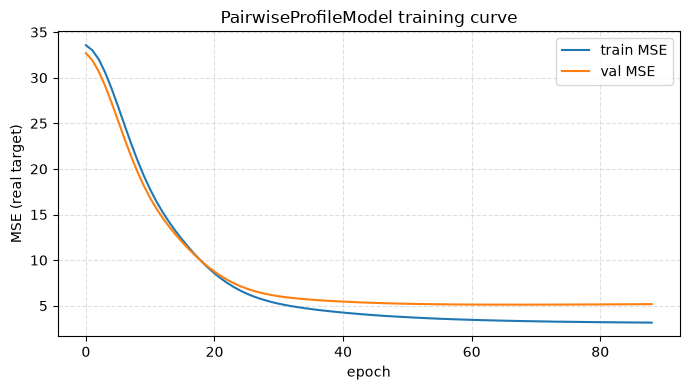

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_pair["train_loss"], label="train MSE")
ax.plot(hist_pair["val_loss"],   label="val MSE")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (real target)")
ax.set_title("PairwiseProfileModel training curve")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same held-out <code>idx_test</code> top-k population as above, now compared against <code>model_pair</code>'s predictions instead of <code>model_mlp</code>'s.
</div>

In [25]:
pred_train_pair = np.asarray(predict_scores(model_pair, jnp.asarray(Xtr_pair)))
pred_test_pair  = np.asarray(predict_scores(model_pair, jnp.asarray(X_pair_test)))

print("Held-out test comparison -- model_mlp (unrestricted) vs. model_pair (2nd-order only):\n")
print(f"Pearson r (train) -- model_mlp: {pearson(ytr_mlp, pred_train_mlp):.4f}   model_pair: {pearson(ytr_pair, pred_train_pair):.4f}")
print(f"Pearson r (test)  -- model_mlp: {pearson(y_test,  pred_test_mlp):.4f}   model_pair: {pearson(y_test,  pred_test_pair):.4f}")
print()
print("Held-out (test) top-k precision:")
print(f"  {'':>7} {'model_mlp':>10} {'model_pair':>11} {'random':>8}")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p_mlp  = precision_at_k(y_test, pred_test_mlp,  k_frac=frac)
    p_pair = precision_at_k(y_test, pred_test_pair, k_frac=frac)
    print(f"  top {int(frac * 100):>3d}% {p_mlp:>10.3f} {p_pair:>11.3f} {frac:>8.3f}")


Held-out test comparison -- model_mlp (unrestricted) vs. model_pair (2nd-order only):

Pearson r (train) -- model_mlp: 0.9676   model_pair: 0.9084
Pearson r (test)  -- model_mlp: 0.9134   model_pair: 0.8382

Held-out (test) top-k precision:
           model_mlp  model_pair   random
  top   1%      0.155       0.061    0.010
  top   5%      0.422       0.214    0.050
  top  10%      0.582       0.394    0.100
  top  20%      0.741       0.655    0.200


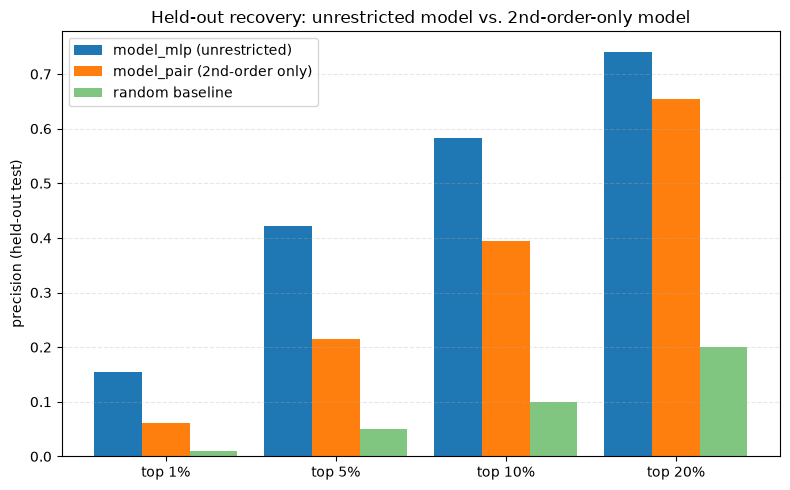

In [26]:
fracs       = [0.01, 0.05, 0.10, 0.20]
p_mlp_vals  = [precision_at_k(y_test, pred_test_mlp,  k_frac=f) for f in fracs]
p_pair_vals = [precision_at_k(y_test, pred_test_pair, k_frac=f) for f in fracs]

x = np.arange(len(fracs))
width = 0.28
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, p_mlp_vals,  width, label="model_mlp (unrestricted)")
ax.bar(x,          p_pair_vals, width, label="model_pair (2nd-order only)")
ax.bar(x + width, fracs,        width, label="random baseline", alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f"top {int(f * 100)}%" for f in fracs])
ax.set_ylabel("precision (held-out test)")
ax.set_title("Held-out recovery: unrestricted model vs. 2nd-order-only model")
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
<code>top_gt_500</code>: the TRUE top-500 by real measured target, computed <b>within the held-out test split only</b> (<code>idx_test</code>) — real, measured, held-out. Distinct from the "top 5,000 by predicted score over the full CSV" set above.
</div>

#### Visualizing the recovery of the top 500 variants

Fixed to a concrete screening budget instead of a library percentage: out of the
**500 real sequences with the highest actual `target`** in the held-out test set, how
many does each model's own top-500 predicted ranking actually catch?

The scatter below is the same `plot_topk_recovery` convention already used for
`model_mlp` in section 3 (green = correctly recovered, blue = a true top-500 sequence
the model missed, orange = a false positive the model over-rated), now with `k` fixed
to exactly 500 instead of a percentage, for both models. The line plot after it tracks
cumulative recovery as you screen more and more top-predicted candidates, with a
marker at the 500 cutoff.


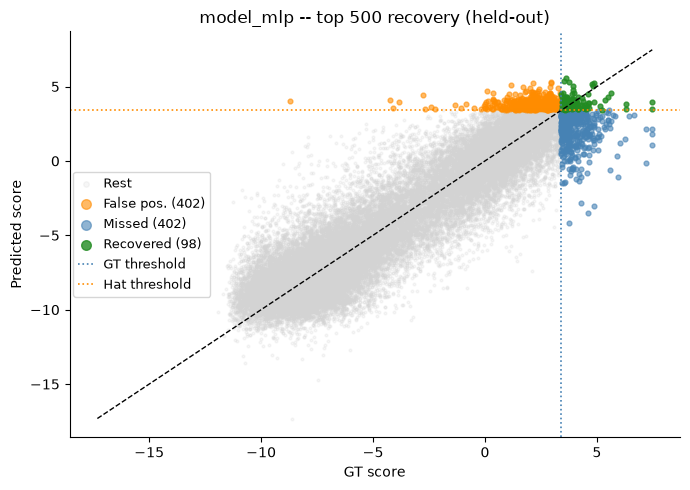

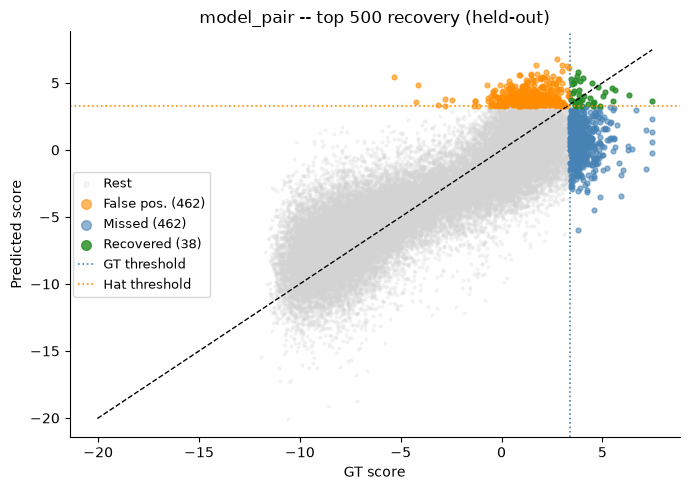

In [27]:
TOP_N = 500
k_frac_500 = TOP_N / len(y_test)

fig_mlp  = plot_topk_recovery(y_test, pred_test_mlp,  k_frac=k_frac_500, title=f"model_mlp -- top {TOP_N} recovery (held-out)")
plt.show()

fig_pair = plot_topk_recovery(y_test, pred_test_pair, k_frac=k_frac_500, title=f"model_pair -- top {TOP_N} recovery (held-out)")
plt.show()


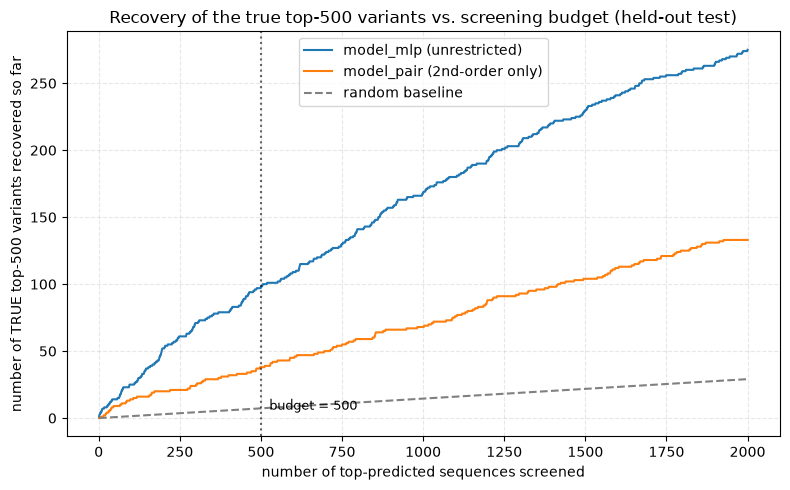

At a screening budget of exactly 500:
  model_mlp  recovers 98/500 (19.6%) of the true top-500 variants
  model_pair recovers 38/500 (7.6%) of the true top-500 variants
  random baseline expectation: 7.3/500 (1.5%)


In [28]:
N_test     = len(y_test)
top_gt_500 = set(np.argsort(-y_test)[:TOP_N])  # indices of the true top-500 sequences (by real target)

def cumulative_recovery(score_hat, top_gt, max_rank):
    """For each screening budget b in [1, max_rank], how many of `top_gt` are among the
    b highest-scoring sequences by score_hat."""
    order     = np.argsort(-score_hat)[:max_rank]
    recovered = np.isin(order, list(top_gt))
    return np.cumsum(recovered)

max_rank    = 2000  # screen up to this many top-predicted candidates, well past the 500 cutoff
ranks       = np.arange(1, max_rank + 1)
recov_mlp   = cumulative_recovery(pred_test_mlp,  top_gt_500, max_rank)
recov_pair  = cumulative_recovery(pred_test_pair, top_gt_500, max_rank)
recov_rand  = ranks * (TOP_N / N_test)  # expected recovery count under a random ranking

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ranks, recov_mlp,  label="model_mlp (unrestricted)")
ax.plot(ranks, recov_pair, label="model_pair (2nd-order only)")
ax.plot(ranks, recov_rand, linestyle="--", color="gray", label="random baseline")
ax.axvline(TOP_N, color="black", linestyle=":", alpha=0.6)
ax.annotate(f"budget = {TOP_N}", (TOP_N, 0), textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_xlabel("number of top-predicted sequences screened")
ax.set_ylabel(f"number of TRUE top-{TOP_N} variants recovered so far")
ax.set_title(f"Recovery of the true top-{TOP_N} variants vs. screening budget (held-out test)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

n_mlp_500  = int(recov_mlp[TOP_N - 1])
n_pair_500 = int(recov_pair[TOP_N - 1])
print(f"At a screening budget of exactly {TOP_N}:")
print(f"  model_mlp  recovers {n_mlp_500}/{TOP_N} ({n_mlp_500 / TOP_N:.1%}) of the true top-{TOP_N} variants")
print(f"  model_pair recovers {n_pair_500}/{TOP_N} ({n_pair_500 / TOP_N:.1%}) of the true top-{TOP_N} variants")
print(f"  random baseline expectation: {TOP_N * TOP_N / N_test:.1f}/{TOP_N} ({TOP_N / N_test:.1%})")


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Reuses <code>top_gt_500</code> (held-out true top-500, above) but the background is now a <b>new</b> uniformly-random sample of 2,000,000 synthetic sequences drawn from the full 20^7 ≈ 1.28-billion-sequence combinatorial space — a random synthetic baseline, not real, not a "top" of anything.
</div>

#### `model_pair` against the full sequence landscape (brute-force 2M-variant background)

The held-out test set above is only ~34k sequences from one curated experimental
library -- not a fair picture of the full `20**7 ~= 1.28e9`-sequence space. This
instead follows the same brute-force convention used elsewhere in the project
(`N = 2_000_000` uniform-random sequences, e.g.
`selectivity_weight_regimes/MLP_for_independent_weights.ipynb`): draw 2,000,000
sequences uniformly at random from the full space, score them with `model_pair`, and
see where the REAL top-500 variants (by actual measured `target`) land relative to
that much larger, unbiased background.


In [29]:
key  = jax.random.key(42)
N_BG = 2_000_000
seq_bg = jax.random.randint(key, shape=(N_BG, num_positions), minval=0, maxval=num_amino_acids)

pred_bg_pair = batched_predict(model_pair, seq_bg)
print(f"Scored {N_BG:,} sequences drawn uniformly from the full "
      f"{num_amino_acids}**{num_positions} = {num_amino_acids ** num_positions:,}-sequence space with model_pair.")
print(f"model_pair score over this random background: mean={pred_bg_pair.mean():.3f}  std={pred_bg_pair.std():.3f}")


Scored 2,000,000 sequences drawn uniformly from the full 20**7 = 1,280,000,000-sequence space with model_pair.
model_pair score over this random background: mean=-4.301  std=3.840


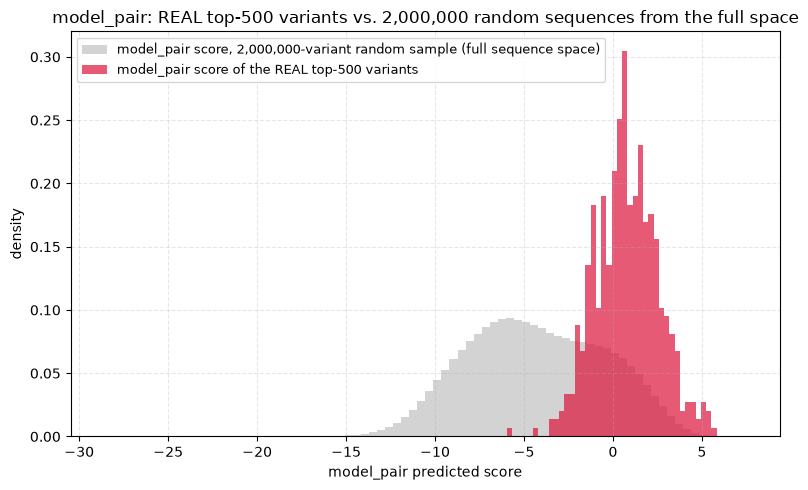

model_pair-score percentile of the REAL top-500 variants, vs. the 2,000,000-variant random background:
  median = 89.0th percentile   min = 36.0th percentile   max = 100.0th percentile
  31/500 land in the background's own top 1%   223/500 land in its top 10%


In [30]:
pred_pair_true_top500 = pred_test_pair[list(top_gt_500)]  # model_pair's scores on the REAL top-500 (from above)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pred_bg_pair, bins=80, density=True, color="lightgray",
        label=f"model_pair score, {N_BG:,}-variant random sample (full sequence space)")
ax.hist(pred_pair_true_top500, bins=40, density=True, color="crimson", alpha=0.7,
        label=f"model_pair score of the REAL top-{TOP_N} variants")
ax.set_xlabel("model_pair predicted score")
ax.set_ylabel("density")
ax.set_title(f"model_pair: REAL top-{TOP_N} variants vs. {N_BG:,} random sequences from the full space")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

bg_sorted = np.sort(pred_bg_pair)
percentile = 100 * np.searchsorted(bg_sorted, pred_pair_true_top500, side="left") / len(bg_sorted)
print(f"model_pair-score percentile of the REAL top-{TOP_N} variants, vs. the {N_BG:,}-variant "
      f"random background:")
print(f"  median = {np.median(percentile):.1f}th percentile   min = {np.min(percentile):.1f}th percentile   "
      f"max = {np.max(percentile):.1f}th percentile")
print(f"  {int((percentile >= 99).sum())}/{TOP_N} land in the background's own top 1%   "
      f"{int((percentile >= 90).sum())}/{TOP_N} land in its top 10%")


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same <code>top_gt_500</code> (held-out true top-500) overlaid here on an <b>exhaustive</b> histogram of the entire ~1.28-billion-sequence combinatorial space (no sampling) — the background is the full theoretical landscape, not a top-K list.
</div>

#### Does model_pair place the REAL true-best variants where they should be? (exhaustive, no sampling)

`model_pair` has literal closed-form `F`/`J` parameters -- no neural net forward pass needed
to score a sequence, just gather + sum -- so unlike `model_mlp`, scoring EVERY one of the
`20**7` possible sequences (not a 2,000,000-variant random sample) is cheap. This exhaustively
scores the entire space in GPU chunks, accumulates it into a histogram, and overlays the
**REAL top-500 variants (by actual measured `target`)** on it -- the same brute-force spirit
as `brute_force_top_k` elsewhere in the project, but built as a full histogram instead of a
top-k list, since the question here is "where do the real best sequences fall in the whole
landscape," not "what does model_pair itself think the single best sequence is."


In [31]:
@jax.jit
def _rawidx_chunk(idx, L=num_positions, A=num_amino_acids):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    return jnp.stack(digits[::-1], axis=1).astype(jnp.int32)


total      = num_amino_acids ** num_positions
chunk_size = 20_000_000
bin_edges  = np.linspace(-45, 30, 151)
bg_counts  = np.zeros(len(bin_edges) - 1, dtype=np.int64)
bg_min, bg_max = np.inf, -np.inf

for start in tqdm(range(0, total, chunk_size), desc="model_pair exhaustive scan"):
    end = min(start + chunk_size, total)
    idx = jnp.arange(start, end)
    seq_chunk    = _rawidx_chunk(idx)
    scores_chunk = np.asarray(predict_scores(model_pair, seq_chunk))
    bg_counts   += np.histogram(scores_chunk, bins=bin_edges)[0]
    bg_min = min(bg_min, float(scores_chunk.min()))
    bg_max = max(bg_max, float(scores_chunk.max()))

print(f"Exhaustively scored ALL {total:,} possible sequences with model_pair (no sampling).")
print(f"observed score range: [{bg_min:.2f}, {bg_max:.2f}]  (histogram range: [{bin_edges[0]}, {bin_edges[-1]}])")
if bg_min < bin_edges[0] or bg_max > bin_edges[-1]:
    print("WARNING: some scores fell outside the histogram range -- widen bin_edges.")



model_pair exhaustive scan:   0%|          | 0/64 [00:00<?, ?it/s]


model_pair exhaustive scan:   2%|▏         | 1/64 [00:00<00:40,  1.57it/s]


model_pair exhaustive scan:   3%|▎         | 2/64 [00:00<00:25,  2.42it/s]


model_pair exhaustive scan:   5%|▍         | 3/64 [00:01<00:18,  3.25it/s]


model_pair exhaustive scan:   6%|▋         | 4/64 [00:01<00:15,  3.89it/s]

...


model_pair exhaustive scan:  97%|█████████▋| 62/64 [00:11<00:00,  5.51it/s]


model_pair exhaustive scan:  98%|█████████▊| 63/64 [00:11<00:00,  5.55it/s]


model_pair exhaustive scan: 100%|██████████| 64/64 [00:11<00:00,  5.55it/s]


model_pair exhaustive scan: 100%|██████████| 64/64 [00:11<00:00,  5.34it/s]

Exhaustively scored ALL 1,280,000,000 possible sequences with model_pair (no sampling).
observed score range: [-37.80, 23.97]  (histogram range: [-45.0, 30.0])


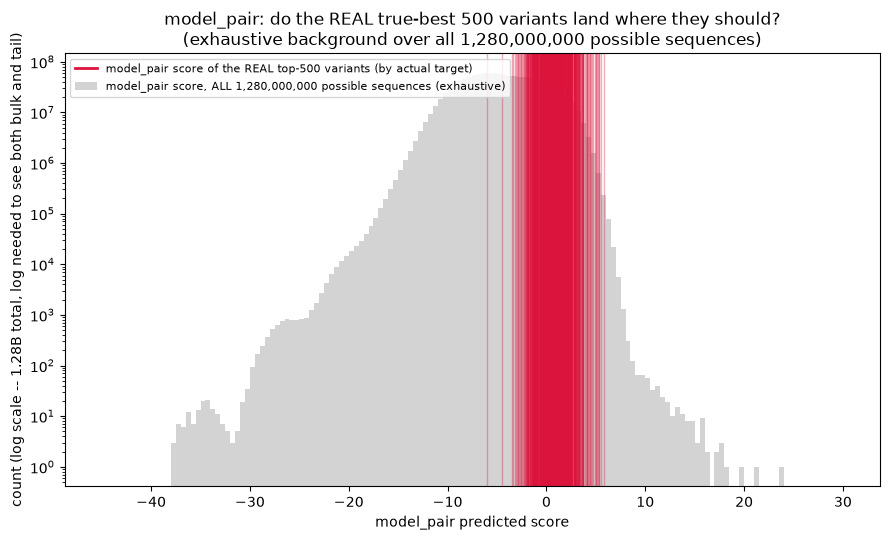

model_pair-score percentile of the REAL top-500 variants, vs. the EXHAUSTIVE 1,280,000,000-sequence background (approximate, binned to 150 bins):
  median = 87.45th percentile   min = 35.74th percentile   max = 99.97th percentile
  29/500 land in the background's own top 1%   215/500 land in its top 10%


In [32]:
top_gt_500_ordered = np.argsort(-y_test)[:TOP_N]          # REAL top-500 indices, ordered best-first by actual target
pred_pair_true_top500_ordered = pred_test_pair[top_gt_500_ordered]  # model_pair's scores on them, same order

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(bin_centers, bg_counts, width=np.diff(bin_edges), color="lightgray",
       label=f"model_pair score, ALL {total:,} possible sequences (exhaustive)")
for v in pred_pair_true_top500_ordered:
    ax.axvline(v, color="crimson", alpha=0.35, lw=1)
ax.axvline(pred_pair_true_top500_ordered[0], color="crimson", lw=2,
           label=f"model_pair score of the REAL top-{TOP_N} variants (by actual target)")
ax.set_yscale("log")
ax.set_xlabel("model_pair predicted score")
ax.set_ylabel("count (log scale -- 1.28B total, log needed to see both bulk and tail)")
ax.set_title(f"model_pair: do the REAL true-best {TOP_N} variants land where they should?\n"
             f"(exhaustive background over all {total:,} possible sequences)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

cum_counts    = np.cumsum(bg_counts)
total_counted = cum_counts[-1]
bin_idx       = np.clip(np.searchsorted(bin_edges, pred_pair_true_top500_ordered, side="right") - 1, 0, len(bg_counts) - 1)
below         = np.where(bin_idx > 0, cum_counts[bin_idx - 1], 0)
percentile    = 100 * below / total_counted

print(f"model_pair-score percentile of the REAL top-{TOP_N} variants, vs. the EXHAUSTIVE "
      f"{total:,}-sequence background (approximate, binned to {len(bg_counts)} bins):")
print(f"  median = {np.median(percentile):.2f}th percentile   min = {np.min(percentile):.2f}th percentile   "
      f"max = {np.max(percentile):.2f}th percentile")
print(f"  {int((percentile >= 99).sum())}/{TOP_N} land in the background's own top 1%   "
      f"{int((percentile >= 90).sum())}/{TOP_N} land in its top 10%")


### 7. Direct profile model — construct the 140 weights directly

`ProfileMLP` above only reveals an effective `F` indirectly: it predicts a
scalar score through a black-box network, then `F` has to be pulled out
afterward with an expensive single-mutant scan. Here the model *is* the
`(num_amino_acids, num_positions)` profile matrix — no hidden layers, no
per-sequence nonlinearity: `score(seq) = bias + sum_i F[seq_i, i]`, the
exact functional form the naive profile already uses. It's trained with the
same nnx machinery as section 3 (`train_profile_mlp`, reused via its
`model=` warm-start argument), but the regression target for each sequence
is the score the **naive** profile (`F_viab_GT`) would predict for it — not
the noisy real `target` — so this checks whether gradient descent, using
this project's own training loop, converges to the same answer as the
closed-form per-position averaging.


# This does not work, we just find the noisy distribution, our goal is to predict the log enrichment of a variants base of his sequence, this deterministic model is easy to find by grandient descent but it is the noisy distribution, we don't want to recover this exact distribution.

In [33]:
raise SystemExit("checkpoint — stop ici")

SystemExit: checkpoint — stop ici

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [34]:
class DirectProfileModel(nnx.Module):
    """
    The model *is* the profile matrix: F (num_amino_acids, num_positions) and a scalar bias
    are the only trainable parameters, used exactly like Protocol.compute_score's profile
    term -- score(seq) = bias + sum_i F[seq_i, i]. `train`/`rngs` are accepted (unused) only
    so this matches ProfileMLP's call signature and can be dropped straight into train_step/
    eval_step/train_profile_mlp without changing any of that code.
    """

    def __init__(self, num_amino_acids: int, num_positions: int, *, rngs: nnx.Rngs):
        self.F    = nnx.Param(jax.random.normal(rngs.params(), (num_amino_acids, num_positions)) * 0.01)
        self.bias = nnx.Param(jnp.zeros(()))

    def __call__(self, x: jax.Array, *, train: bool = False, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        idx = x.astype(jnp.int32)
        return self.F[idx, jnp.arange(idx.shape[1])].sum(axis=1) + self.bias[...]


In [35]:
baseline   = target.mean()
naive_pred = baseline + F_viab_GT[seq_matrix, np.arange(num_positions)].sum(axis=1)
print(f"Pearson r (naive_pred vs real target): {pearson(target, naive_pred):.4f}")

# Same idx_train/idx_test/seq_matrix split as section 3's ProfileMLP -- only the regression
# target changes (naive_pred instead of the real target).
y_naive_train = naive_pred[idx_train]
y_naive_test  = naive_pred[idx_test]

Xtr_direct, ytr_direct, Xva_direct, yva_direct = split_train_val(X_mlp_train_full, y_naive_train, val_frac=0.15, seed=0)
print(f"DirectProfileModel -- train: {len(Xtr_direct):,}  val: {len(Xva_direct):,}  test: {len(X_mlp_test):,}")

model_direct_init = DirectProfileModel(num_amino_acids=num_amino_acids, num_positions=num_positions, rngs=nnx.Rngs(0))
model_direct, hist_direct = train_profile_mlp(
    Xtr_direct, ytr_direct, Xva_direct, yva_direct, model=model_direct_init, seed=0
)


Pearson r (naive_pred vs real target): 0.7788
DirectProfileModel -- train: 29,230  val: 5,158  test: 34,388



Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]


Training ProfileMLP:   0%|          | 1/300 [00:00<01:19,  3.75it/s]


Training ProfileMLP:   3%|▎         | 8/300 [00:00<00:11, 26.32it/s]


Training ProfileMLP:   5%|▌         | 15/300 [00:00<00:07, 40.46it/s]

...


Training ProfileMLP:  17%|█▋        | 51/300 [00:01<00:03, 63.08it/s]


Training ProfileMLP:  19%|█▉        | 58/300 [00:01<00:03, 62.82it/s]


Training ProfileMLP:  22%|██▏       | 65/300 [00:01<00:03, 61.96it/s]


Training ProfileMLP:  22%|██▏       | 65/300 [00:01<00:04, 52.01it/s]

Early stopping at epoch 65 (best val MSE=9.0562)


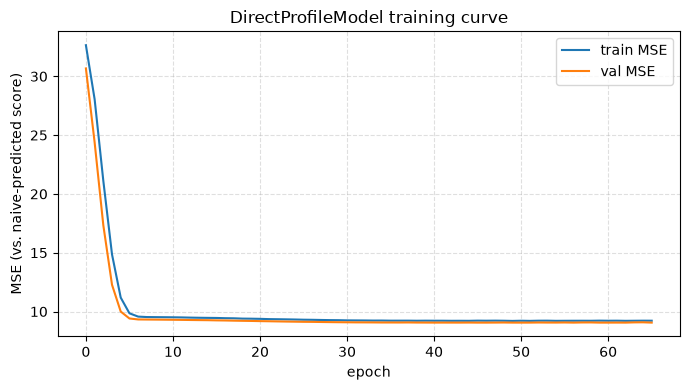

Pearson r (predictions vs. naive-predicted scores, held-out test): 0.1824
Pearson r (F_direct vs F_viab_GT, raw 140 weights): -0.3142


In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_direct["train_loss"], label="train MSE")
ax.plot(hist_direct["val_loss"],   label="val MSE")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (vs. naive-predicted score)")
ax.set_title("DirectProfileModel training curve")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

pred_test_direct = np.asarray(predict_scores(model_direct, jnp.asarray(X_mlp_test)))
print(f"Pearson r (predictions vs. naive-predicted scores, held-out test): {pearson(y_naive_test, pred_test_direct):.4f}")

F_direct = np.array(model_direct.F[...])
print(f"Pearson r (F_direct vs F_viab_GT, raw 140 weights): {pearson(F_viab_GT.ravel(), F_direct.ravel()):.4f}")


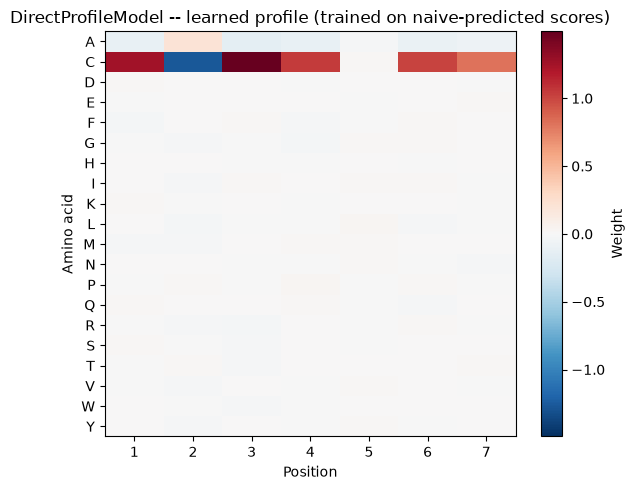

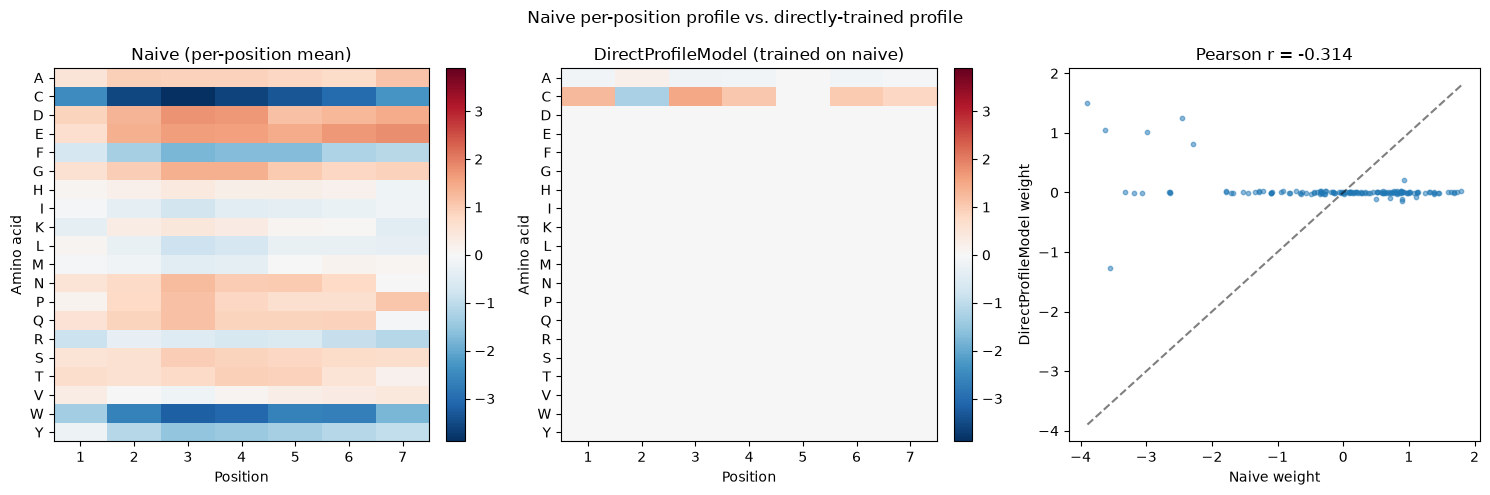

In [37]:
plot_teacher_weights(F_direct, title="DirectProfileModel -- learned profile (trained on naive-predicted scores)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vmax = max(np.abs(F_viab_GT).max(), np.abs(F_direct).max())

for ax, F, title in [(axes[0], F_viab_GT, "Naive (per-position mean)"), (axes[1], F_direct, "DirectProfileModel (trained on naive)")]:
    im = ax.imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel("Amino acid")
    ax.set_xticks(range(num_positions))
    ax.set_xticklabels([str(i) for i in range(1, num_positions + 1)])
    ax.set_yticks(range(num_amino_acids))
    ax.set_yticklabels(AA_LABELS)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

r_profiles = pearson(F_viab_GT.ravel(), F_direct.ravel())
axes[2].scatter(F_viab_GT.ravel(), F_direct.ravel(), s=10, alpha=0.5)
lims = [min(F_viab_GT.min(), F_direct.min()), max(F_viab_GT.max(), F_direct.max())]
axes[2].plot(lims, lims, "k--", alpha=0.5)
axes[2].set_xlabel("Naive weight")
axes[2].set_ylabel("DirectProfileModel weight")
axes[2].set_title(f"Pearson r = {r_profiles:.3f}")

fig.suptitle("Naive per-position profile vs. directly-trained profile")
fig.tight_layout()
plt.show()


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same held-out <code>idx_test</code> top-k population as the first box above, now applied to <code>DirectProfileModel</code> instead of <code>model_mlp</code>.
</div>

Pearson r (train): 0.1520
Pearson r (test):  0.1444

Held-out (test) top-k recovery vs the REAL target (not naive_pred):
  Top   1%   precision = 0.009   (random baseline = 0.010)
  Top   5%   precision = 0.037   (random baseline = 0.050)
  Top  10%   precision = 0.095   (random baseline = 0.100)
  Top  20%   precision = 0.220   (random baseline = 0.200)


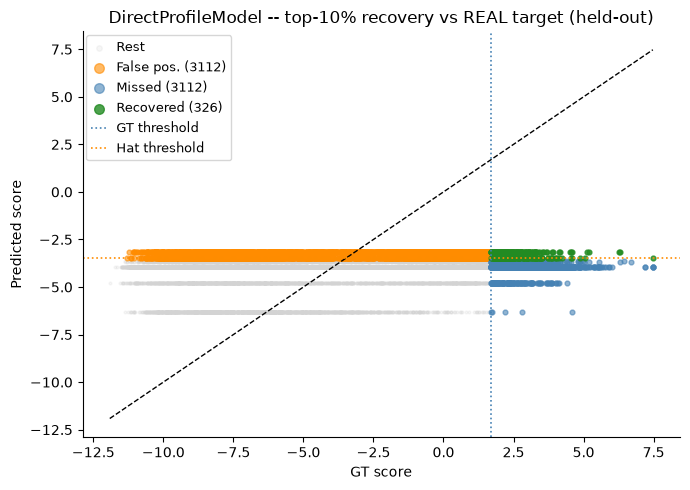

In [38]:
@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)

pred_train_direct = np.asarray(predict_scores(model_direct, jnp.asarray(Xtr_mlp)))
pred_test_direct  = np.asarray(predict_scores(model_direct, jnp.asarray(X_mlp_test)))

print(f"Pearson r (train): {pearson(ytr_mlp, pred_train_direct):.4f}")
print(f"Pearson r (test):  {pearson(y_test,  pred_test_direct):.4f}")
print()
print("Held-out (test) top-k recovery vs the REAL target (not naive_pred):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_test, pred_test_direct, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_test, pred_test_direct, k_frac=0.10, title="DirectProfileModel -- top-10% recovery vs REAL target (held-out)")
plt.show()


**Why MSE → 0 during training:** `naive_pred` is, by construction, exactly
`bias + sum_i F[seq_i, i]` — the same functional form `DirectProfileModel`
uses. There's no noise in that target: it's a deterministic linear function
of the 140+1 unknowns, and `DirectProfileModel` has exactly those 140+1
unknowns as its only parameters. MSE is a convex (quadratic) function of a
linear model's own parameters, and a zero-residual solution provably exists
(`F = F_viab_GT`, `bias = baseline`) — so Adam just has to find that global
minimum, which it does (train *and* val loss hit ~0, since neither split
has any label noise to leave a residual). This is not overfitting: it's
gradient descent rediscovering the exact linear system that generated the
label in the first place.

**Why recovering ≈ the same `F` doesn't mean recovering the best real
variants:** matching `F_viab_GT` only proves the training pipeline
converges correctly — it says nothing about whether the *naive* profile
itself is good at ranking real variants, and `DirectProfileModel` was
deliberately trained to reproduce naive, not the real `target`, so its
ceiling is capped at naive's own accuracy (r ≈ 0.78 either way). At r²≈0.61
that ceiling sounds decent — but precision@k above shows it collapses at
the extreme top (**top-1% precision = 0.000**), while `ProfileMLP` two
sections up — *lower* overall r (0.36) — gets **7.4× the random baseline**
at that same top-1% (0.074 vs. 0.010). An additive, single-site model's own
best-ranked sequences necessarily cluster around "the single best amino
acid at every position" — it structurally cannot represent any real
variant whose extreme enrichment comes from a *specific combination* of
positions (epistasis). It gets the coarse split right (this project's own
bimodal target from section 1b: "probably dead" vs. "probably viable" —
that's most of where the top-10/20% numbers come from) but is blind to
whatever finer, non-additive effect separates the literal best variants
from the merely-good ones — and `ProfileMLP`, despite a noisier overall
fit, can at least partially see that.